In [2]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

In [3]:
import os
import pandas as pd

if os.path.exists('data/youtube.csv'):
    data_path = 'data/youtube.csv'
elif os.path.exists('/content/youtube.csv'):
    data_path = '/content/youtube.csv'
else:
    raise FileNotFoundError("Dataset not found. Please upload youtube.csv to the Colab session.")

df = pd.read_csv(data_path)

In [4]:
df.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201,6/2/2016 0:00,0,2,6,2016,Thursday,0.024,723,...,0,0,40.38,81,23531,533.1636,51,0.561,41118,27.66
1,1,391,6/10/2016 0:00,8,10,6,2016,Friday,0.056,727,...,0,0,39.85,156,11478,500.5628,33,0.648,41627,5.85
2,2,133,6/14/2016 0:00,4,14,6,2016,Tuesday,0.014,76,...,0,0,30.88,41,6153,70.7287,8,0.089,38713,7.07
3,3,14,6/29/2016 0:00,15,29,6,2016,Wednesday,0.004,18,...,0,0,103.05,14,4398,17.6251,2,0.017,35245,5.60
4,4,45,7/1/2016 0:00,2,1,7,2016,Friday,0.000,0,...,0,0,55.70,25,14659,104.3341,28,0.000,46218,8.62


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    int64  
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    int64  
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                           364 non-n

**Data Preprocessing**

Handle Missing Values

In [6]:
df.isnull().sum()

,0
ID,0
Video Duration,0
Video Publish Time,0
Days Since Publish,0
Day,0
...,...
Watch Time (hours),0
Subscribers,0
Estimated Revenue (USD),0
Impressions,0


No missing values in the dataset.

convert "Video Publish Time" to a datetime type and extract meaningful features.

In [7]:
df['Video Publish Time'] = pd.to_datetime(df['Video Publish Time'])

df['Publish Year'] = df['Video Publish Time'].dt.year
df['Publish Month'] = df['Video Publish Time'].dt.month
df['Publish Day'] = df['Video Publish Time'].dt.day

df = df.drop(columns=['Video Publish Time'])

LabelEncoding on 'Day of Week' column

In [8]:
label_encoder = LabelEncoder()
df['Day of Week'] = label_encoder.fit_transform(df['Day of Week'])

In [9]:
print(df['Day of Week'].value_counts())

Day of Week
3    63
5    60
6    57
0    54
2    49
1    46
4    35
Name: count, dtype: int64


# **Exploratory Data Analysis (EDA)**

In [10]:
df.describe(include="all").to_csv("descriptive_stats.csv")

**Descriptive Summary**

*   Views: On average, videos got around 128,800 views, but there's a huge difference between the best and worst performers. The minimum was 2,461 views and the maximum was 670,990 views. Since the median is 101,950 views, it means half the videos got fewer than this amount, suggesting a few videos received a lot more views and boosted the overall average.

*  Watch Time: The videos had an average of about 10,059 hours of watch time. However, this varied dramatically, from just 12.7 hours to over 53,795 hours. The median of 8,103 hours shows that half the videos were watched for less time than the average. This suggests that a few very popular videos had exceptionally long watch times.

*   Estimated Revenue: The average revenue was around $8.85, but this number is misleading. There was a wide range, from $0.00 to a high of $103.12. With a median of just $4.29, it's clear that many videos earned very little, while a small number of videos earned a lot.


*   Subscribers: On average, videos gained about 321 subscribers. However, the results were very mixed. The number of new subscribers ranged from a loss of 3 subscribers to a gain of 3,728. The median of 180 subscribers indicates that while a few videos were subscriber-magnets, many others didn't perform as well.

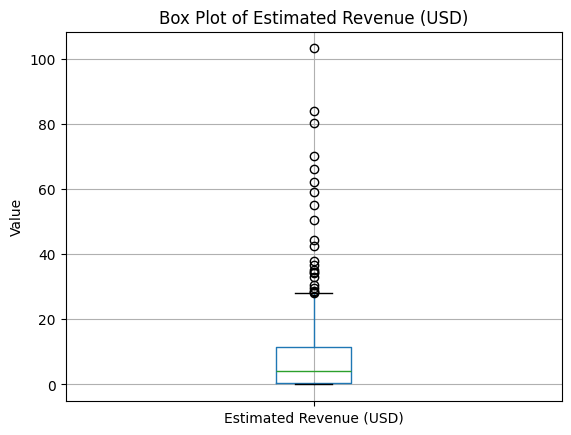

In [11]:
df.boxplot(column='Estimated Revenue (USD)')
plt.title('Box Plot of Estimated Revenue (USD)')
plt.ylabel('Value')
plt.show()

This box plot tells us that the data for estimated revenue is heavily skewed to the right.

*   Most videos earn very little. The box, which represents the middle 50% of the data, is very small and is located at the low end of the revenue scale, close to $0.00. This indicates that half of the videos earned a very small amount of revenue.
*   A few videos are high earners. The long line extending to the right is called a whisker. It shows a wide range of higher revenue values. This indicates that a small number of videos made a disproportionately high amount of money, pulling the maximum revenue value far above the earnings of most videos.


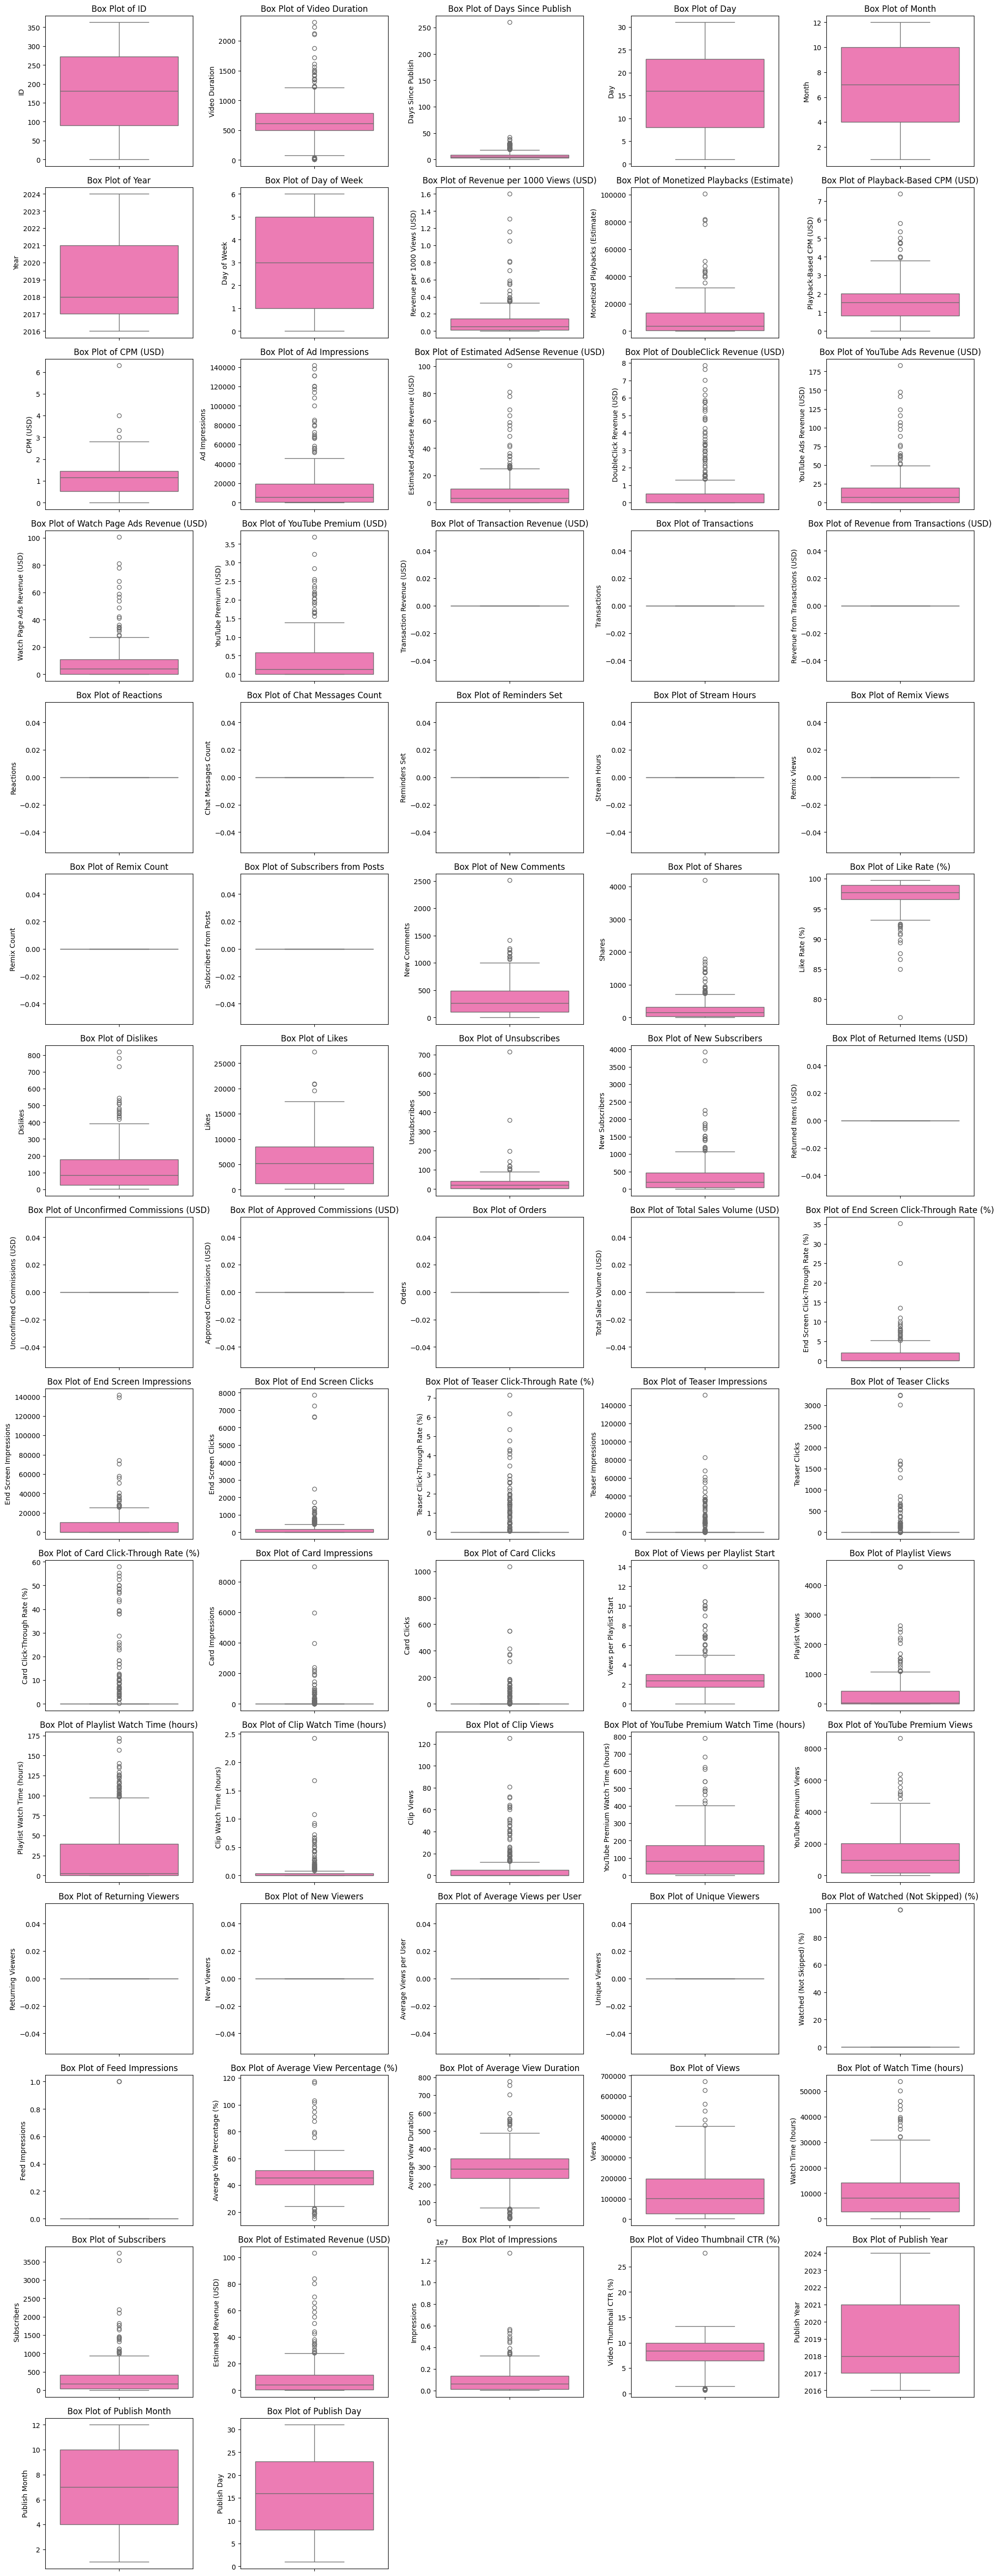

In [12]:
# 1) Pick numeric columns safely
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2) Grid size
n_cols = 5
n_plots = len(num_cols)
n_rows = math.ceil(n_plots / n_cols) if n_plots else 1

# 3) Make subplots and flatten axes for 1D indexing
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(4*n_cols, 3.5*n_rows), squeeze=False)
axes = axes.flatten()

# 4) Draw one box per numeric column
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#FF69B4')
    axes[i].set_title(f'Box Plot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=10)

# 5) Hide any unused axes
for j in range(n_plots, n_rows * n_cols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Observations and Conclusions from Boxplots

- **Counts (Views, Impressions, Watch Time, Likes, Comments, Revenue):**  
  Very right-skewed with many outliers → **A few videos drive most performance.**

- **Engagement rates (Like Rate %, Thumbnail CTR %, Avg View %):**  
  Moderate spread, bounded, fewer extreme outliers → **Useful quality indicators that vary meaningfully across videos.**

- **End-screen/Teaser/Card CTRs:**  
  Centered near very low values with occasional spikes → **Most videos get little end-screen/card interaction.**

- **Average View Duration & Average View %:**  
  Wide IQRs and long upper whiskers → **Watch quality differs a lot between videos.**

- **Monetized Playbacks & RPM/CPM:**  
  Long-tailed with high outliers → **Earnings efficiency fluctuates widely across videos.**

- **Revenue components (AdSense, DoubleClick, YouTube Ads, Watch-page Ads, Premium):**  
  Similar shapes and tails → **Components are closely related and move together.**

- **Transaction/Orders/Sales metrics:**  
  Boxes collapsed at zero → **Commercial transactions rarely occur.**

- **Reactions / Reminders set / Stream hours / Remix metrics:**  
  Almost flat at zero → **Features are inactive for most videos.**

- **Subscriber flows (New subs, Unsubs):**  
  Mostly low with a few spikes → **Growth happens in bursts on a small set of videos.**

- **Shares & Comments:**  
  Heavy-tailed distributions → **A minority of videos drive most social activity.**

- **Playlist metrics (starts, views, clicks):**  
  Many zeros with rare high points → **Playlists contribute sporadically.**

- **Unique viewers vs Views & Avg views per user:**  
  Unique viewers spread is narrower; avg views per user low → **Most viewers watch once or a few times; repeat viewing is limited.**

- **YouTube Premium views/watch time:**  
  Small values with limited spread → **Premium audience is a small fraction.**

- **Video Duration:**  
  Broad spread with upper outliers → **Both short and long formats are present; a few very long videos.**

- **Days since publish:**  
  Extremely skewed toward newer content → **Dataset is dominated by recently published videos with a few very old ones.**

- **Publish day/month/day-of-week:**  
  Fairly even boxes without strong skew → **Publishing is relatively balanced across calendar slots.**

- **Impressions vs Thumbnail CTR:**  
  Both show variation → **Reach and click-through vary independently and both matter for views.**

- **Likes vs Dislikes:**  
  Dislikes are low and tightly packed; likes are right-skewed → **Sentiment is generally positive; a few videos attract most likes.**

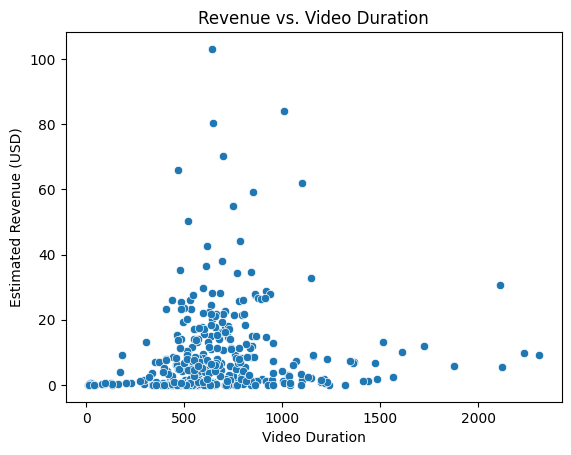

In [13]:
sns.scatterplot(x='Video Duration', y='Estimated Revenue (USD)', data=df)
plt.title('Revenue vs. Video Duration')
plt.show()

## 1) Revenue vs. Video Duration (scatter)
- **Observation:** Highest revenue points cluster around **~400–1000 seconds** (≈ 7–16 min). Very **short (<200s)** and **very long (>1500s)** videos rarely earn much.
- **Conclusion:** **Duration alone is not a strong predictor**; there’s a **sweet spot at mid-length**. Don’t just make videos longer—optimize around ~8–15 minutes and focus on watch quality.


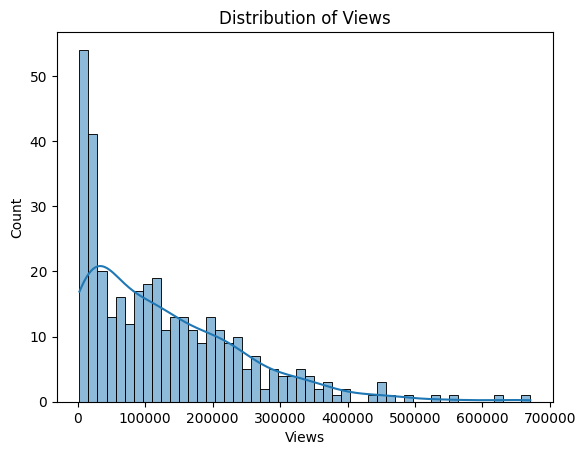

In [14]:
sns.histplot(df['Views'], bins=50, kde=True)
plt.title('Distribution of Views')
plt.show()

## 2) Distribution of Views (histogram)
- **Observation:** Views are **heavy right-skewed** with a long tail; most videos are **below ~150k** views while a few reach **400k–650k+**.
- **Conclusion:** A **small number of hits drive most reach**. Use **median/IQR** for reporting and **log-scale features** for modeling.


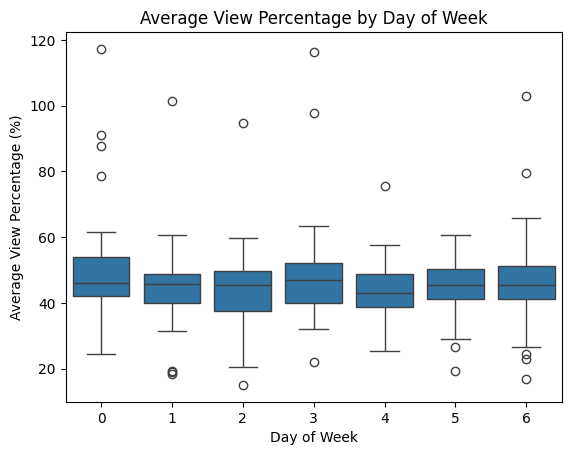

In [15]:
sns.boxplot(x='Day of Week', y='Average View Percentage (%)', data=df)
plt.title('Average View Percentage by Day of Week')
plt.show()

## 3) Average View Percentage by Day of Week (boxplots)
- **Observation:** Medians sit around **~42–50%** across all days with **overlapping IQRs**; no clear “best” day. A few **outliers >100%** indicate data issues.
- **Conclusion:** **Day-of-week effect is weak**; scheduling matters less than content/thumbnail quality. **Cap/clean** avg-view-% at **100** and focus on improving retention/CTR instead.

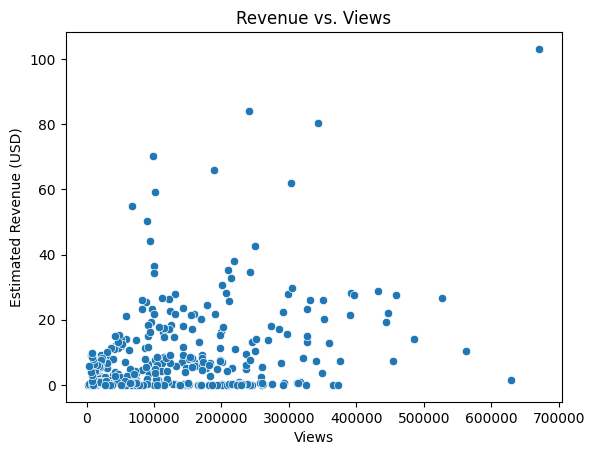

In [16]:
sns.scatterplot(x='Views', y='Estimated Revenue (USD)', data=df)
plt.title('Revenue vs. Views')
plt.show()

- **Observation:** Revenue generally rises with views, but the points are very scattered—some high-view videos still earn little.
- **Conclusion:** Views alone don’t guarantee revenue; improve monetization efficiency (watch time/retention, ad eligibility, premium audience) to boost RPM.


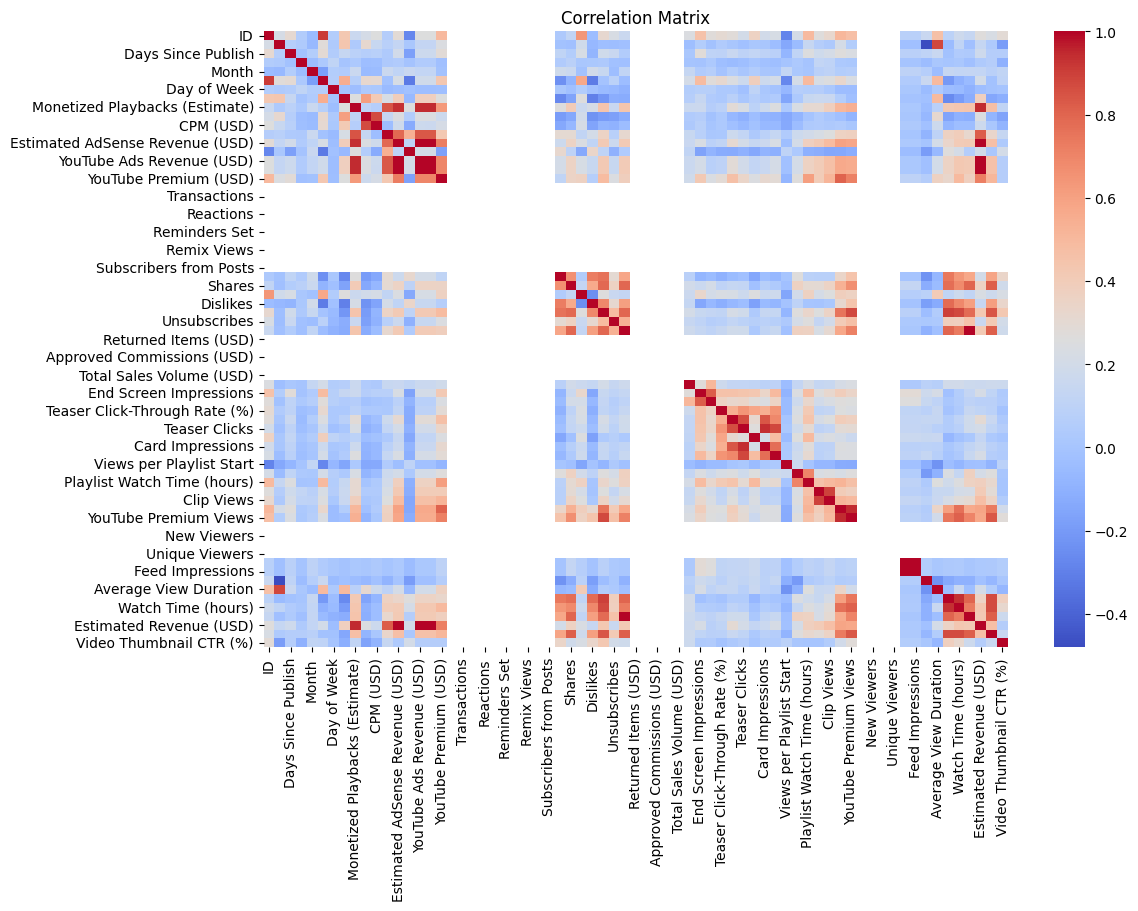

In [17]:
numeric_data = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=False, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Correlation Insights (Target: **Estimated Revenue (USD)**)

## 1) Strong positive relationships (main drivers)
- **Watch Time (hours)** and **Views / Clip Views / Playlist Watch Time** → Revenue rises mainly with *viewing volume*.
- **Monetized Playbacks (Estimate)** → Closely tied to ad delivery; increases track revenue.
- **Revenue components** (**Estimated AdSense Revenue, YouTube Ads Revenue, YouTube Premium (USD)**) → Move almost one-for-one with the target.  
  **Conclusion:** Revenue is dominated by **reach × watch time × monetization**. These are the core predictors.

> ⚠️ Note: The three “revenue components” and **RPM/CPM** are **target-leakage risks** (they contain or derive from revenue). Prefer not to use them to train a model that predicts total revenue.

## 2) Moderate positive relationships (useful secondary signals)
- **Unique Viewers, Impressions, Feed Impressions** → Broader reach generally lifts revenue.
- **Average View Duration & Average View %** → Better retention correlates with more revenue at similar reach.
- **Thumbnail CTR (%)** → Higher click-through modestly supports revenue by converting impressions to views.
- **New Subscribers** → Growth events co-occur with higher-earning videos.  
  **Conclusion:** Keep these as **quality and funnel** features; they add lift beyond raw reach.

## 3) Weak/near-zero relationships (low priority)
- **Calendar features** (*Month, Day of Week, Publish Day/Month/Year*) → Little linear link to revenue in this snapshot.
- **End Screen / Teaser / Card CTRs & Clicks** → Mostly weak; effects are small or indirect.
- **Shares, Comments, Likes (counts)** → Positive but comparatively small once reach is accounted for.  
  **Conclusion:** Keep only if you engineer **rates** (per 1k views) or use in interaction terms.

## 4) Likely negative or negligible signals
- **Dislikes, Unsubscribes** → Slight negative tendency at best.
- **Transactions / Orders / Sales / Commissions / Reminders / Reactions / Remix metrics** → Mostly zero-heavy and weakly related.  
  **Conclusion:** Drop or convert to **binary “any vs none”** if you keep them.

## 5) Multicollinearity clusters to handle
- **Revenue family:** Estimated Revenue ↔ AdSense ↔ YouTube Ads ↔ Premium ↔ Monetized Playbacks ↔ **RPM/CPM** (very tight cluster).  
  **Action:** Use **only one** of these (ideally none besides the target) to avoid leakage/multicollinearity.
- **Reach/Watch cluster:** Views, Watch Time, Unique Viewers, Impressions are mutually correlated.  
  **Action:** Keep them but consider **regularization** or **tree models**; avoid duplicative engineered features.

---

## Recommended feature plan (safe for modeling)
- **Keep (primary):** `Views`, `Watch Time (hours)`, `Unique Viewers`, `Impressions`, `Average View Duration`, `Average View %`, `Thumbnail CTR (%)`.
- **Keep (secondary):** `New Subscribers (rate)`, `Shares/1k views`, `Comments/1k views`, `Likes/1k views`.
- **Drop/avoid (leakage or weak):** `Estimated AdSense Revenue`, `YouTube Ads Revenue`, `YouTube Premium (USD)`, `RPM`, `CPM`, `Monetized Playbacks (Estimate)`, `Transactions/Orders/Sales/Commissions`, most **Reminders/Reactions/Remix** metrics, raw social **counts** without normalization.
- **Engineer:** Convert counts to **rates per 1k views**; consider interaction `Impressions × CTR` (proxy for views) and **content age buckets** from `Days Since Publish`.

**Bottom line:** Predicting *Estimated Revenue* works best by modeling **reach → clicks → watch quality** (Impressions, CTR, Views, Watch Time, Retention), while **excluding direct revenue components and RPM/CPM** to prevent leakage.


# **Modeling Part**

In [18]:
# Define features and target variable
X = df.drop(columns=['Estimated Revenue (USD)'])
y = df['Estimated Revenue (USD)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, predictions)

    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R²: {r2}")

# Evaluate models
print("Linear Regression:")
evaluate_model(lr, X_test, y_test)

print("\nRandom Forest:")
evaluate_model(rf, X_test, y_test)

Linear Regression:
MAE: 0.0003141141019098191
MSE: 2.2939341457860065e-07
RMSE: 0.00047895032579444043
R²: 0.9999999973653017

Random Forest:
MAE: 0.2618743835616456
MSE: 0.22953128126438796
RMSE: 0.4790942300470628
R²: 0.9973637182364415
